# Project 2: Reinforcement Learning

### Group number
### Student Name 1
### Student Name 2
### ...

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code and plots shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In Project 1, you were asked to implement two exact algorithms to solve the Frozen Lake. In this project, you will be asked to implement four different model-free algorithms to solve a similar problem with larger state space, and compare your results.

## 1. The Flags Domain

In the Flags domain, time is broken up into discrete decision periods, and the world is a
square area that is broken up into a 5-by-5 grid of cells, as illustrated in Figure 1 below.
At the beginning of each period, a robot occupies one of the available cells. It is then
allowed to choose a direction of movement (up, down, left or right), and moves to the
corresponding adjacent cell in that direction. However, if the chosen action would take
the robot outside the boundaries of the grid, the robot does not move but remains in
the current cell.

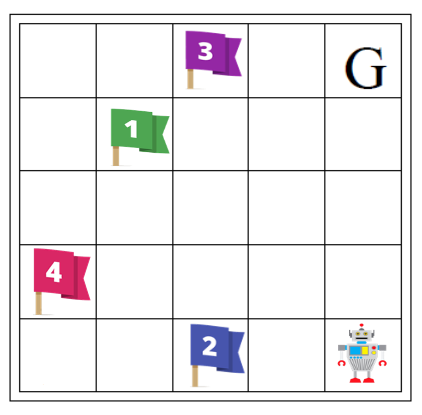



<h1><center>Figure 1: 5x5 Flags Domain</center></h1>

In each episode, the robot begins in the right lower corner. As illustrated in Figure 1, instead of a single
destination G, there are four different flags, numbered 1, 2, 3 and 4, that must be
collected in the correct order (first 1, then 2, etc... to 4). Once the robot has collected all the flags in the correct order and lands on cell G, the task is complete. If the robot collects the wrong flag at the wrong time (e.g. tries to collect 2 first, then 1...), the robot does not have to start over. Instead, the robot is penalized for taking this action, and the wrong flag is not collected (you may assume for training purposes, that the flags that have already been collected so far are kept). The main objective is to collect all the flags in the correct order in the least possible amount of time.

### 2. Problem modelling [15 Marks]

You are tasked with modelling the Flags environment. Then, you are asked to provide a programming description of the problem that will be used to solve it computationally using model-free reinforcement learning.

2.1.Answer the following questions:

(a) Define the state $(S)$ and action spaces $(A)$.[2 Marks]

State Space:

Pairs of: (Grid position (i,j), Flag most recently acquired (k))

Action Space:

{L, R, U, D}

(b) Construct a reward function ($R$) that aligns with the goal(s) you want your robot to achieve. [2 Marks]

R(s',a, s)

-Manhattan distance between robot location and flag k+1

-1000 for flags > k+1 

(c) Based on Figure 1, what is an optimal policy for this problem? You may explain your policy by drawing Figure 1 and trace the path the robot should take. Is there more than one optimal policy?[3 Marks]

2.2 Implement the dynamics of the Flags environment. [8 Marks]

In [15]:
# imports
import random
from matplotlib import pyplot as plt

In [34]:
class Flags:
    def __init__(self):
        self.init_state = (4, 4, 0)     # state tuple (x, y, recent_flag_captured). recent_flag_captured = 0 if none captured
        self.goal_state = (0, 4, 4)     
        self.goal_loc = (0, 4)
        self.flag_locs = {1: (1, 1), 2: (4, 2), 3: (0, 2), 4: (3, 0), 5: (0, 4)}
        self.loc_flags = {(1, 1): 1, (4, 2): 2, (0, 2): 3, (3, 0): 4, (0, 4): 5}
        self.map_action_to_movement = {'l': (0, -1), 'r': (0, 1), 'u': (-1, 0), 'd': (1, 0)}

    # return the initial state ...
    def reset(self):
        return self.init_state

    # return a list containing all the possible states in the environment
    def states_space(self):
        return [(x, y, flag) for x in range(5) for y in range(5) for flag in range(5)]

    # return a list containing all the possible actions corresponding to the given state
    def actions_space(self, state):
        return ['l', 'r', 'u', 'd']
    
    def check_valid_action(self, action): 
        if action not in ['l', 'r', 'u', 'd']:
            raise ValueError("Action is invalid.")

    # checks whether the provided grid location is within bounds
    def check_valid_loc(self, loc): 
        if not(0 <= loc[0] <= 4) or not(0 <= loc[1] <= 4):
            return False
        return True
    
    # dense reward
    def reward(self, state, next_state):
        new_loc, curr_flag, new_flag = next_state[:2], state[-1], next_state[-1]
        
        # check whether the state is already goal state
        if next_state == self.goal_state:
            return 0

        penalty = 0
        # if new location on grid is the wrong order flag or the goal state without having captured all 4 flags, penalize
        if (new_loc in self.loc_flags and self.loc_flags[new_loc] > curr_flag + 1) or (new_loc in self.goal_loc and new_flag < 4):
            penalty = -20
        
        if new_flag < 4:
            target = self.flag_locs[new_flag + 1]
        else:   # if all 4 flags captured already
            target = self.goal_loc

        # return negative manhattan distance to the next flag/goal
        return -1*(abs(target[0] - new_loc[0]) + abs(target[1] - new_loc[1])) + penalty
    
    # environment transition returns s' and r.
    def transition(self, state, action):

        self.check_valid_action(action)
        
        # get new location with given state and action
        movement = self.map_action_to_movement[action]
        new_loc, curr_flag = (state[0] + movement[0], state[1] + movement[1]), state[-1]

        if not self.check_valid_loc(new_loc): # if new_loc is out of bounds, don't move
            new_loc = state[:2]

        # if collected all flags
        if curr_flag == 4:
            if new_loc == self.goal_loc:
                next_state = self.goal_state
            else:
                next_state = (new_loc[0], new_loc[1], curr_flag)
        else:
            # if the new grid location has a flag and it is the next flag, capture it
            if new_loc in self.loc_flags and self.flag_locs[curr_flag + 1] == new_loc:
                next_state = (new_loc[0], new_loc[1], curr_flag + 1)
            # if not the next flag, don't capture
            else:
                next_state = (new_loc[0], new_loc[1], curr_flag)
        
        return next_state, self.reward(state, next_state)

In [35]:
env = Flags()
test_states = [
    # given valid states
    (4, 4, 0), # work swell
    (1, 2, 0), # works well
    (4, 1, 1), # works well
    (2, 1, 1), # works well
    (0, 1, 1), # works well
    (4, 0, 2), # works well
    (0, 3, 3), # works well
    (0, 3, 4), # works well

    # given goal state
    (0, 4, 4),
]
for state in test_states:
    rewards = []
    for action in ['l', 'r', 'u', 'd']:
        _, reward = env.transition(state, action)
        rewards.append(reward)
    print(f"For {state} with 4 actions, reward is {rewards}.")

For (4, 4, 0) with 4 actions, reward is [-5, -6, -5, -6].
For (1, 2, 0) with 4 actions, reward is [-4, -2, -22, -2].
For (4, 1, 1) with 4 actions, reward is [-2, -4, -2, -1].
For (2, 1, 1) with 4 actions, reward is [-4, -2, -4, -2].
For (0, 1, 1) with 4 actions, reward is [-6, -24, -5, -4].
For (4, 0, 2) with 4 actions, reward is [-6, -5, -25, -6].
For (0, 3, 3) with 4 actions, reward is [-5, -27, -6, -5].
For (0, 3, 4) with 4 actions, reward is [-2, 0, -1, -2].
For (0, 4, 4) with 4 actions, reward is [-1, 0, 0, -1].


### 3 Monte Carlo Method [35 Marks]

In this section, you are asked to implement Monte Carlo methods to solve the flags domain. Use a discount factor of
$\gamma= 0.99$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point, the episode ends.Training should proceed for a total of 2000 episodes.


3.1.Create a function $generate\_episode$ which takes as input a policy $\pi$ and the environment. This function should return the tuple of states, actions and rewards generated in an episode following $\pi$.    [5 Marks]

In [34]:
# Maybe we should make a class? 


In [31]:
# 3.1

def generate_episode(init_state: tuple, init_action: str, policy: dict, env: Flags):
    env.reset()
    goal_state = env.goal_state
   
    curr_state, init_reward = env.transition(init_state, init_action)
    states, actions, rewards = [init_state], [init_action], [init_reward]
    t = 1   # since S_0, A_0, R_1 already initialized and appended to array

    while curr_state != goal_state and t < 200:
        action = random.choices(env.actions_space(curr_state), weights=policy[curr_state])[0]
        next_state, reward = env.transition(curr_state, action)
        states.append(curr_state)               # S_t
        actions.append(action)                  # A_t
        rewards.append(reward)                  # R_t+1
        curr_state = next_state
        t += 1
    
    return states, actions, rewards

3.2.Implement the first-visit Monte Carlo (for $\epsilon$-soft policies) control algorithm to find the approximate optimal
policy $\pi^*$. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and include plots in your report for each of these values. What is the best value of $\epsilon$? Why? For each $\epsilon$, did your algorithm converge at all? What was the final policy and
Q-values that you typically obtain (typically, as in the majority of the trials)? Does this correspond to an optimal policy? Visualize the learning process (for instance, change in Q for some state; or any other visualization) to support your claims.  [15 Marks]

In [32]:
# 3.2 

def first_visit_mc(epsilon: float, env: Flags):
    gamma = 0.99
    all_states, all_actions = env.states_space(), ['l', 'r', 'u', 'd']

    # initialize stochastic policy as equiprobable for all actions
    # assume the stochastic policy follows this format {key=state: value=[prob of 'l', prob of 'r', prob of 'u', prob of 'd']}
    policy = {state: [1/len(all_actions)]*len(all_actions) for state in all_states} # {state:list of probs}  
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} # {(state, action):q-value}
    returns = {(state, action): [] for state in all_states for action in env.actions_space(state)} # {(state, action):[g_1, ... g_t]}

    for _ in range(2000):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action
        rand_action = random.choices(env.actions_space(rand_state), weights=policy[rand_state])[0]

        # generate eposode for the chosen state and action
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, policy, env)
        pairs = [(state_ep[i], action_ep[i]) for i in range(len(state_ep))]
        g = 0
        for t in range(len(state_ep) - 1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            prev_pairs = set(pairs[:t])
            g = (gamma * g) + reward_ep[t]

            # if first visit
            if (curr_state, curr_action) not in prev_pairs:
                returns[(curr_state, curr_action)].append(g)
                q[(curr_state, curr_action)] = sum(returns[(curr_state, curr_action)]) / len(returns[(curr_state, curr_action)])

                # find argmax_a [Q(S,a)]
                best_q, a_star = 0, 'l'
                for action in all_actions:
                    if q[(curr_state, action)] > best_q:
                        a_star = action
                        best_q = q[(curr_state, action)]
                
                for i, action in enumerate(all_actions):
                    policy[curr_state][i] = 1 - epsilon + (epsilon / len(env.actions_space(curr_state))) if action != a_star else epsilon / len(env.actions_space(curr_state))

            
    return policy, q


In [33]:
env = Flags()

for epsilon in (0.01, 0.1, 0.25):
    pi, q = first_visit_mc(epsilon, env)
    # plot the q function at each flag state, for every 100th episode
    # for each flag state, show the action with highest probabilty, for every 100th episode
    print(f"Epsilon = {epsilon}")
    print(pi)
    print(q)


Epsilon = 0.01
{(0, 0, 0): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 0, 1): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 0, 2): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 0, 3): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 0, 4): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 1, 0): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 1, 1): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 1, 2): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 1, 3): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 1, 4): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 2, 0): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 2, 1): [0.0025, 0.9924999999999999, 0.9924999999999999, 0.9924999999999999], (0, 2, 2): [

3.3.Consider a random behavior policy $b(a|s)=1/|A|$ for every state and action. Use episodes generated with $b$ to find the approximate optimal policy $\pi^*$. First use ordinary importance sampling Monte Carlo control. Then use weighted importance sampling Monte Carlo control. Answer the same questions as in 3.2.  [15 Marks]

### 4 Temporal Diference Control Methods [25 Marks]

In this section, you are asked to implement SARSA and Q-learning methods to solve the flags domain. Use a discount factor of $\gamma= 0.99$ and a learning rate of $\alpha = 0.3$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point.Training should proceed for a total of 500 episodes.

4.1. Implement the off-policy Q-learning algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2. [13 Marks]

4.2. Implement on-policy one-step Sarsa algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2.[12 Marks]

### 5 Comparing Algorithms [25 Marks]

In the final section of your report, you must compare the different control algorithm you implemented on the Flags domain. In particular, please comment on at least the following issues in your report:

(a) Were the Q-value functions and policies you obtained using each algorithm similar? Were they different? Comment on this using the properties of each algorithm you learned in class [6 Marks]

(b) Use the plots you created for each ε to make a detailed comparison of the performance of the algorithms implemented in 3.2, 4.1 and 4.2. Answer the following questions for each ε you tested. Which one converged the fastest on average? Which one the slowest? Which one
had lower variance and which had higher variance? Why? [6 Marks]

(c) choose one particular ε for all three algorithms and one of the importance sampling Monte Carlo control, compare their testing performances of policies learned by all the algorithm (try to visualize this comparison). [13 Marks]